In [37]:
# Install required libraries
%pip install -q transformers datasets tokenizers

import pandas as pd
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from transformers import PreTrainedTokenizerFast

print("1. Loading raw data from BOTH datasets...")
ctg_df = pd.read_csv('ctg_full_text.csv')
delivery_df = pd.read_csv('delivery.csv')

# Build one shared corpus so tokenizer learns words from both tasks
ctg_texts = ctg_df['clinical_text'].dropna().astype(str).str.lower().tolist()
delivery_texts = delivery_df['caption'].dropna().astype(str).str.lower().tolist()
texts = ctg_texts + delivery_texts

print(f"Total text samples for tokenizer training: {len(texts)}")
print("2. Building the shared WordPiece dictionary...")

# Initialize a blank WordPiece tokenizer
raw_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))

# Add normalizer and pre-tokenizer
raw_tokenizer.normalizer = normalizers.Sequence([normalizers.Lowercase()])
raw_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Train tokenizer on shared corpus
trainer = trainers.WordPieceTrainer(
    vocab_size=3000,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)
raw_tokenizer.train_from_iterator(texts, trainer=trainer)

# Wrap for Transformers compatibility
my_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=raw_tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

# Save shared tokenizer
my_tokenizer.save_pretrained("./my_perfect_tokenizer")
print(f"✅ Shared tokenizer saved. Vocabulary size: {my_tokenizer.vocab_size}")

# Quick sanity checks from both datasets
test_ctg = "Baseline fetal heart rate is 110 bpm. Severe prolonged decelerations present."
test_delivery = "Presentation breech. First stage duration 240 minutes. Late decelerations observed."

ctg_tokens = my_tokenizer.tokenize(test_ctg.lower())
delivery_tokens = my_tokenizer.tokenize(test_delivery.lower())

print("\nCTG test tokens:", ctg_tokens)
print("Delivery test tokens:", delivery_tokens)
print("CTG [UNK] count:", ctg_tokens.count("[UNK]"))
print("Delivery [UNK] count:", delivery_tokens.count("[UNK]"))

1. Loading raw data from BOTH datasets...
Total text samples for tokenizer training: 2678
2. Building the shared WordPiece dictionary...
✅ Shared tokenizer saved. Vocabulary size: 894

CTG test tokens: ['baseline', 'fetal', 'heart', 'rate', 'is', '110', 'bpm', '.', 'severe', 'prolonged', 'decelerations', 'present', '.']
Delivery test tokens: ['presentation', 'breech', '.', 'first', 'stage', 'duration', '240', 'minutes', '.', 'late', 'decelerations', 'o', '##b', '##se', '##r', '##v', '##ed', '.']
CTG [UNK] count: 0
Delivery [UNK] count: 0


In [38]:
import pandas as pd
from datasets import Dataset
from transformers import (
    BertConfig,
    BertForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    PreTrainedTokenizerFast,
    set_seed,
    default_data_collator,
    EvalPrediction,
    TrainerCallback,
    TrainerControl,
    TrainerState,
    )

set_seed(42)

# ==========================================
# STEP 2: DESIGNING THE SHARED MARF-BERT BRAIN
# ==========================================
print("1. Loading shared tokenizer...")
tokenizer = PreTrainedTokenizerFast.from_pretrained("./my_perfect_tokenizer")

print("2. Spawning the blank shared neural network...")
config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=128,
    num_hidden_layers=4,
    num_attention_heads=4,
    intermediate_size=512,
    max_position_embeddings=128
)
model = BertForMaskedLM(config)
print(f"Shared Marf-BERT born! Trainable parameters: {model.num_parameters()}")

# ==========================================
# STEP 3: SHARED MLM PRE-TRAINING (CTG + DELIVERY)
# ==========================================
print("\n3. Preparing shared text corpus from BOTH datasets...")
ctg_df = pd.read_csv('ctg_full_text.csv')
delivery_df = pd.read_csv('delivery.csv')

ctg_texts = ctg_df['clinical_text'].dropna().astype(str).str.lower().tolist()
delivery_texts = delivery_df['caption'].dropna().astype(str).str.lower().tolist()
texts = ctg_texts + delivery_texts

print(f"CTG samples: {len(ctg_texts)} | Delivery samples: {len(delivery_texts)} | Total: {len(texts)}")
dataset = Dataset.from_dict({"text": texts})

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# MLM collator masks 15% tokens
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

print("\n4. Starting shared MLM pre-training...")
training_args = TrainingArguments(
    output_dir="./marf_bert_training_shared",
    num_train_epochs=100,
    per_device_train_batch_size=16,
    logging_steps=50,
    learning_rate=1e-4,
    save_strategy="epoch",
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_datasets,
)

trainer.train()

# Save shared base model for later multitask fine-tuning
trainer.save_model("./MARF_BERT_BASE")
print("\n✅ Success! Shared MARF_BERT_BASE trained on CTG + Delivery text.")

1. Loading shared tokenizer...
2. Spawning the blank shared neural network...
Shared Marf-BERT born! Trainable parameters: 942078

3. Preparing shared text corpus from BOTH datasets...
CTG samples: 2126 | Delivery samples: 552 | Total: 2678


Map:   0%|          | 0/2678 [00:00<?, ? examples/s]


4. Starting shared MLM pre-training...


Step,Training Loss
50,6.253839
100,5.379489
150,4.678458
200,4.146073
250,3.754571
300,3.437893
350,3.111685
400,2.877325
450,2.628817
500,2.431288


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Success! Shared MARF_BERT_BASE trained on CTG + Delivery text.


In [39]:
# 1. Install required libraries for multi-task fine-tuning
%pip install -q evaluate accelerate scikit-learn transformers datasets

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    PreTrainedTokenizerFast,
    BertModel,
    TrainingArguments,
    Trainer,
    set_seed,
    default_data_collator,
    EvalPrediction,
    )

# ==========================================
# 1. PREPARE BOTH TASK DATASETS
# ==========================================
set_seed(42)
print("1. Loading and preparing CTG and Delivery datasets...")

# Task A: CTG fetal health (3 classes)
ctg = pd.read_csv("ctg_full_text_balanced.csv").dropna(subset=["clinical_text", "fetal_health"]).copy()
ctg["text"] = ctg["clinical_text"].astype(str).str.lower()
ctg_label_map = {1.0: 0, 2.0: 1, 3.0: 2}
ctg["label"] = ctg["fetal_health"].map(ctg_label_map).astype(int)
ctg["task_id"] = 0

# Task B: Delivery type (2 classes)
delivery = pd.read_csv("delivery_balanced.csv").dropna(subset=["caption", "delivery_type"]).copy()
delivery["text"] = delivery["caption"].astype(str).str.lower()
delivery_label_map = {"Vaginal": 0, "Cesarean": 1}
delivery["label"] = delivery["delivery_type"].map(delivery_label_map).astype(int)
delivery["task_id"] = 1

# Split each task separately to avoid leakage
ctg_train, ctg_val = train_test_split(
    ctg[["text", "label", "task_id"]],
    test_size=0.2,
    random_state=42,
    stratify=ctg["label"]
)

delivery_train, delivery_val = train_test_split(
    delivery[["text", "label", "task_id"]],
    test_size=0.2,
    random_state=42,
    stratify=delivery["label"]
)

train_df = pd.concat([ctg_train, delivery_train], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
val_df = pd.concat([ctg_val, delivery_val], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print("Train size:", len(train_df), "| Validation size:", len(val_df))
print("Train by task:\n", train_df["task_id"].value_counts())
print("Validation by task:\n", val_df["task_id"].value_counts())

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# ==========================================
# 2. TOKENIZE
# ==========================================
print("2. Tokenizing data...")
tokenizer = PreTrainedTokenizerFast.from_pretrained("./my_perfect_tokenizer")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# ==========================================
# 3. BUILD MULTI-TASK MODEL (SHARED ENCODER + 2 HEADS)
# ==========================================
print("3. Building multi-task Marf-BERT...")

class MarfBertMultiTask(nn.Module):
    def __init__(self, base_model_path="./MARF_BERT_BASE", num_fetal_labels=3, num_delivery_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(base_model_path)
        hidden_size = self.bert.config.hidden_size
        dropout_prob = self.bert.config.hidden_dropout_prob
        self.dropout = nn.Dropout(dropout_prob)
        self.delivery_dropout = nn.Dropout(min(0.35, dropout_prob + 0.15))
        self.fetal_head = nn.Linear(hidden_size, num_fetal_labels)
        self.delivery_head = nn.Sequential(
            self.delivery_dropout,
            nn.Linear(hidden_size, num_delivery_labels),
)
        self.loss_fct = nn.CrossEntropyLoss()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, task_id=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        pooled = self.dropout(outputs.pooler_output)

        fetal_logits = self.fetal_head(pooled)
        delivery_logits = self.delivery_head(pooled)

        loss = None
        if labels is not None and task_id is not None:
            labels = labels.view(-1)
            task_id = task_id.view(-1)
            mask_f = task_id == 0
            mask_d = task_id == 1

            losses = []
            if mask_f.any():
                losses.append(self.loss_fct(fetal_logits[mask_f], labels[mask_f]))
            if mask_d.any():
                losses.append(self.loss_fct(delivery_logits[mask_d], labels[mask_d]))

            if len(losses) == 1:
                loss = losses[0]
            elif len(losses) == 2:
                loss = 0.5 * losses[0] + 0.5 * losses[1]

        return {
            "loss": loss,
            "fetal_logits": fetal_logits,
            "delivery_logits": delivery_logits,
        }

class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        if labels is None:
            labels = inputs.get("label")
        task_id = inputs.get("task_id")

        outputs = model(
            input_ids=inputs.get("input_ids"),
            attention_mask=inputs.get("attention_mask"),
            token_type_ids=inputs.get("token_type_ids"),
            labels=labels,
            task_id=task_id,
        )
        loss = outputs.get("loss", None)
        if loss is None:
            raise ValueError("Loss is None. Ensure both 'labels' and 'task_id' are present in Trainer inputs.")
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred: EvalPrediction):
    # Keep Trainer monitoring on eval_loss for this custom multitask setup.
    return {}

model = MarfBertMultiTask(base_model_path="./MARF_BERT_BASE")

# ==========================================
# 4. TRAIN
# ==========================================
print("4. Starting multi-task fine-tuning...")
training_args = TrainingArguments(
    output_dir="./marf_bert_multitask",
    num_train_epochs=13,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    weight_decay=0.05,
    eval_strategy="epoch",
    save_strategy="epoch",
    remove_unused_columns=False,
    load_best_model_at_end=True,
    report_to="none",
    seed=42
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# Save multitask model weights + tokenizer
os.makedirs("./MARF_BERT_MULTITASK", exist_ok=True)
torch.save(model.state_dict(), "./MARF_BERT_MULTITASK/pytorch_model.bin")
tokenizer.save_pretrained("./MARF_BERT_MULTITASK")
print("\nSaved multi-task weights to ./MARF_BERT_MULTITASK/pytorch_model.bin")
print("Saved tokenizer to ./MARF_BERT_MULTITASK")

1. Loading and preparing CTG and Delivery datasets...
Train size: 4781 | Validation size: 1196
Train by task:
 task_id
0    3972
1     809
Name: count, dtype: int64
Validation by task:
 task_id
0    993
1    203
Name: count, dtype: int64
2. Tokenizing data...


Map:   0%|          | 0/4781 [00:00<?, ? examples/s]

Map:   0%|          | 0/1196 [00:00<?, ? examples/s]

3. Building multi-task Marf-BERT...


Loading weights:   0%|          | 0/69 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ./MARF_BERT_BASE
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


4. Starting multi-task fine-tuning...


Epoch,Training Loss,Validation Loss
1,No log,0.732265
2,0.794716,0.665871
3,0.794716,0.618082
4,0.658660,0.571359
5,0.658660,0.488016
6,0.581673,0.252913
7,0.349079,0.220367
8,0.349079,0.210764
9,0.256892,0.190362
10,0.256892,0.194742



Saved multi-task weights to ./MARF_BERT_MULTITASK/pytorch_model.bin
Saved tokenizer to ./MARF_BERT_MULTITASK


Waking up Marf-BERT multi-task model...
Computing train and validation metrics after each epoch...


Epoch,Training Loss,Validation Loss
1,No log,0.151279
2,0.222424,0.132370
3,0.222424,0.124900
4,0.182327,0.109854
5,0.182327,0.116577
6,0.168809,0.092367
7,0.150975,0.092945
8,0.150975,0.105150
9,0.137822,0.086921
10,0.137822,0.097948



--- TRAIN METRICS ---
CTG / Fetal Health
  accuracy: 0.9620
  f1: 0.9619
  precision: 0.9625
  recall: 0.9620
  auc: 0.9933
  loss: 0.0837
Delivery Type
  accuracy: 0.9889
  f1: 0.9889
  precision: 0.9889
  recall: 0.9889
  auc: 0.9991
  loss: 0.0837

--- VALIDATION METRICS ---
CTG / Fetal Health
  accuracy: 0.9537
  f1: 0.9535
  precision: 0.9557
  recall: 0.9537
  auc: 0.9936
  loss: 0.0850
Delivery Type
  accuracy: 0.9852
  f1: 0.9852
  precision: 0.9853
  recall: 0.9852
  auc: 0.9996
  loss: 0.0850

--- CONFUSION MATRICES (VALIDATION) ---


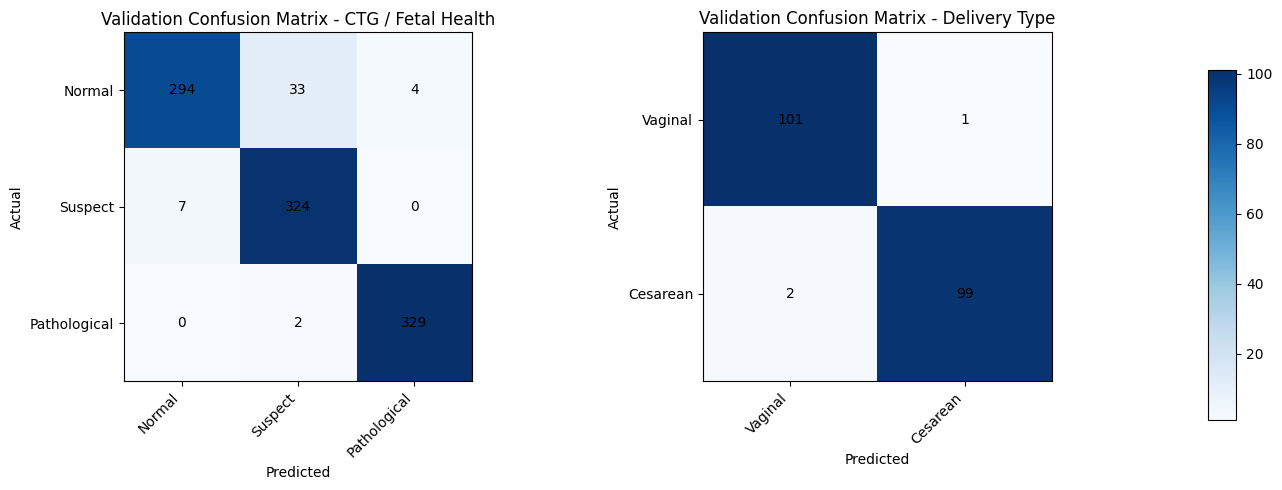


--- TRAIN / VALIDATION CURVES ---


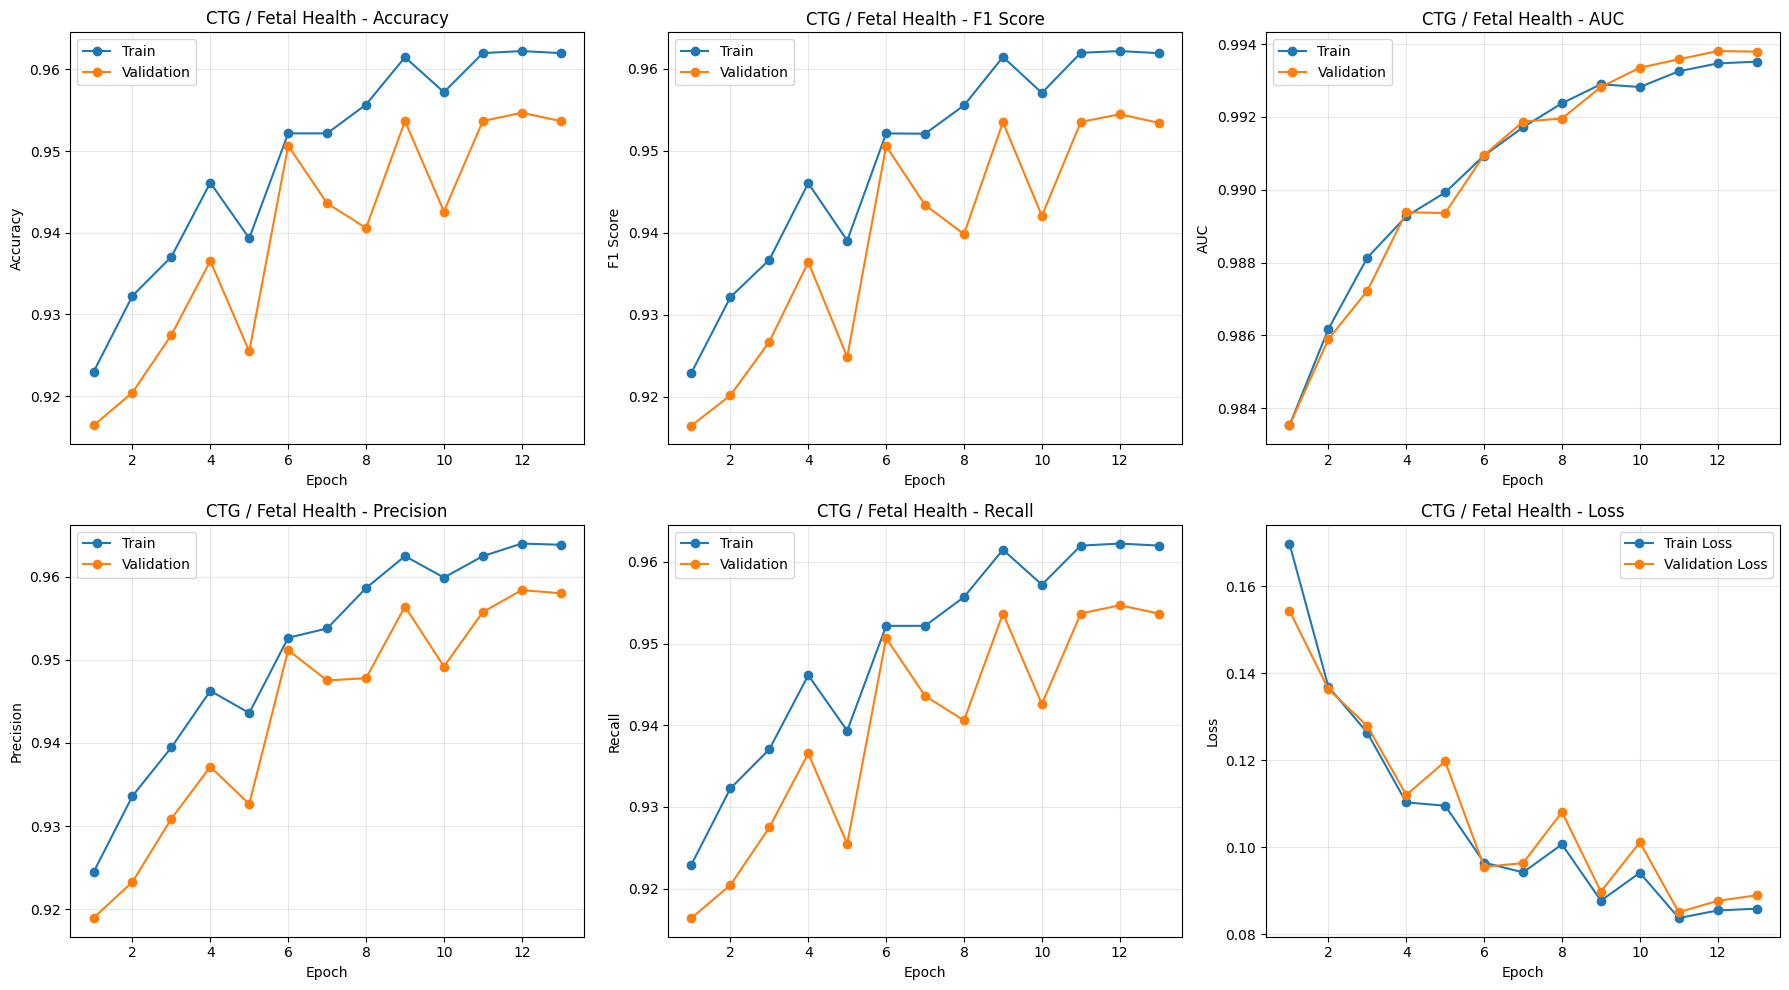

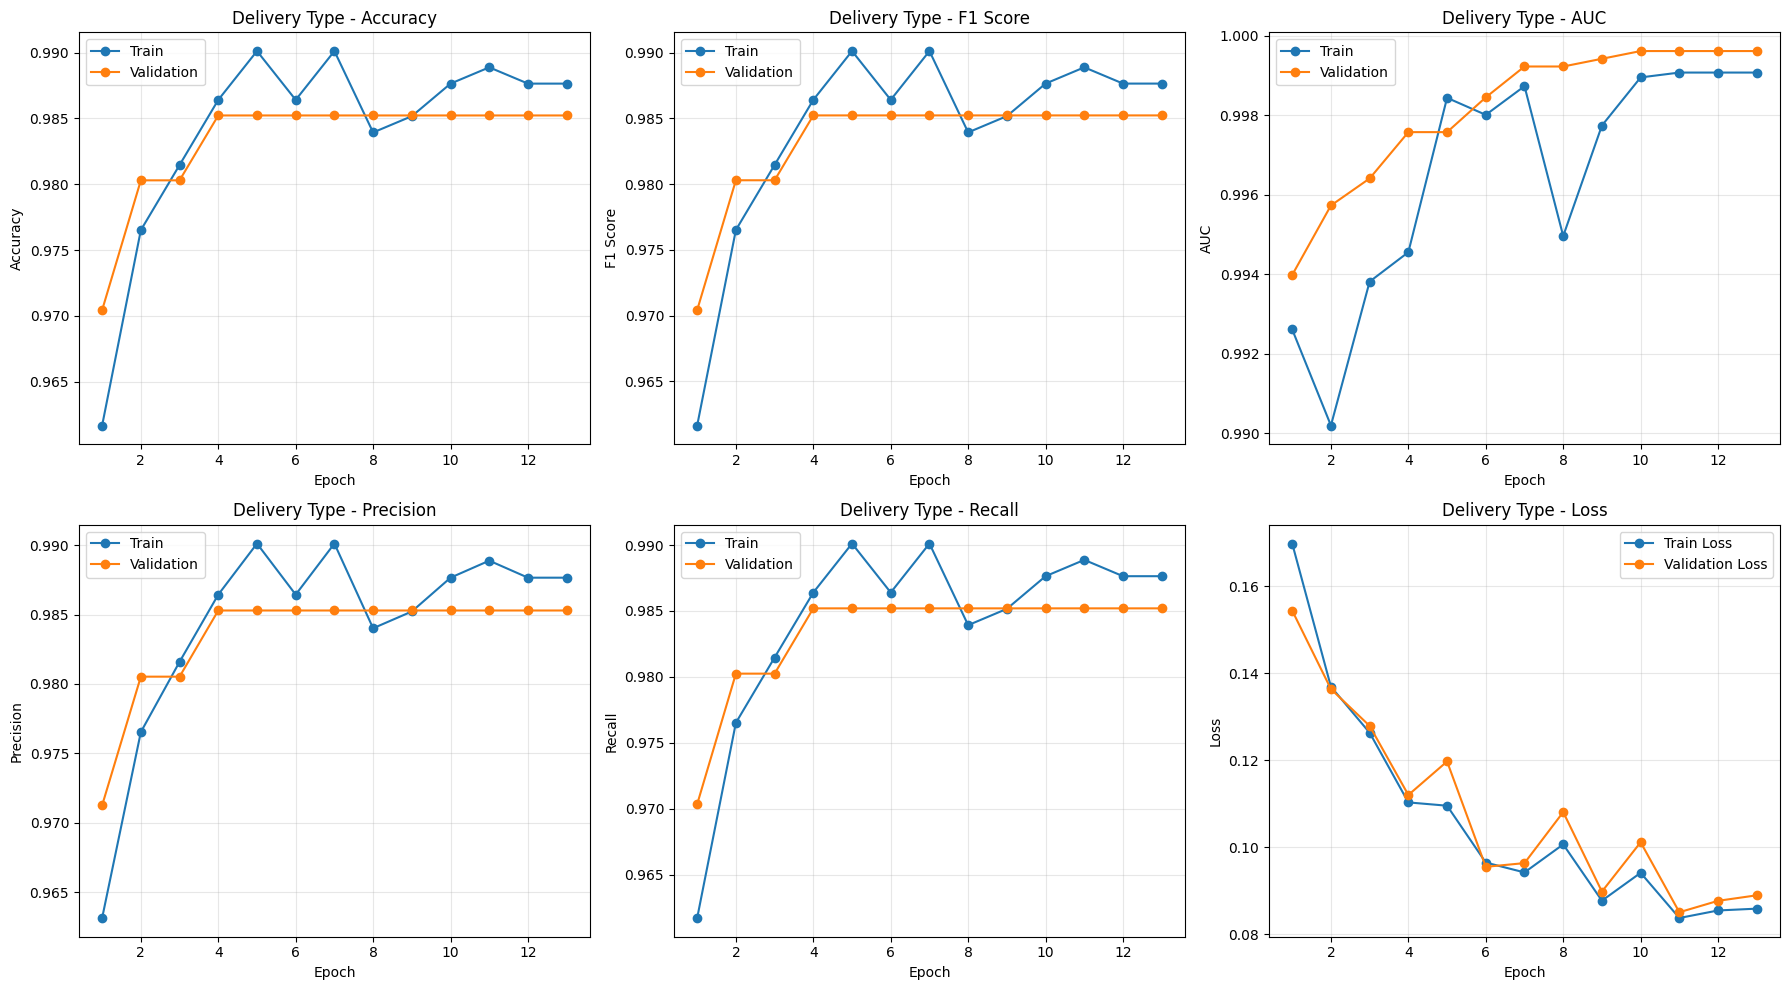


--- UNIFIED PREDICTION EXAMPLE ---
{'fetal_prediction': 'Pathological', 'fetal_probabilities': {'Normal': 0.005308046936988831, 'Suspect': 0.001647838857024908, 'Pathological': 0.9930440783500671}, 'delivery_prediction': 'Cesarean', 'delivery_probabilities': {'Vaginal': 0.011271354742348194, 'Cesarean': 0.9887286424636841}}


In [40]:
# Step 4.1: Multi-task evaluation, confusion matrices, and metric curves

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize
from transformers import PreTrainedTokenizerFast, BertModel, TrainerCallback

# ==========================================
# 1. WAKE UP MARF-BERT (MULTI-TASK VERSION)
# ==========================================
print("Waking up Marf-BERT multi-task model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prefer saved multitask tokenizer; fallback to base tokenizer
tokenizer_dir = "./MARF_BERT_MULTITASK" if os.path.isdir("./MARF_BERT_MULTITASK") else "./my_perfect_tokenizer"
tokenizer = PreTrainedTokenizerFast.from_pretrained(tokenizer_dir)

class MarfBertMultiTask(nn.Module):
    def __init__(self, base_model_path="./MARF_BERT_BASE", num_fetal_labels=3, num_delivery_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(base_model_path)
        hidden_size = self.bert.config.hidden_size
        dropout_prob = self.bert.config.hidden_dropout_prob
        self.dropout = nn.Dropout(dropout_prob)
        self.fetal_head = nn.Linear(hidden_size, num_fetal_labels)
        self.delivery_head = nn.Linear(hidden_size, num_delivery_labels)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        pooled = self.dropout(outputs.pooler_output)
        fetal_logits = self.fetal_head(pooled)
        delivery_logits = self.delivery_head(pooled)
        return {"fetal_logits": fetal_logits, "delivery_logits": delivery_logits}

# Reuse in-memory model if available; otherwise load from saved multitask weights
if "model" in globals() and hasattr(model, "fetal_head") and hasattr(model, "delivery_head"):
    mt_model = model.to(device)
else:
    mt_model = MarfBertMultiTask(base_model_path="./MARF_BERT_BASE")
    weights_path = "./MARF_BERT_MULTITASK/pytorch_model.bin"
    if not os.path.isfile(weights_path):
        raise FileNotFoundError(
            "Missing multitask weights at './MARF_BERT_MULTITASK/pytorch_model.bin'. "
            "Run the multi-task training cell first."
        )
    state_dict = torch.load(weights_path, map_location=device)
    mt_model.load_state_dict(state_dict)
    mt_model = mt_model.to(device)

mt_model.eval()

# ==========================================
# 2. METRICS, CONFUSION MATRICES, AND CURVES
# ==========================================
TASK_INFO = {
    0: {
        "name": "CTG / Fetal Health",
        "labels": ["Normal", "Suspect", "Pathological"],
        "num_labels": 3,
    },
    1: {
        "name": "Delivery Type",
        "labels": ["Vaginal", "Cesarean"],
        "num_labels": 2,
    },
}

METRIC_KEYS = ["accuracy", "f1", "auc", "precision", "recall"]


def _prepare_torch_dataset(dataset):
    keep_columns = ["input_ids", "attention_mask", "label", "task_id"]
    if "token_type_ids" in dataset.column_names:
        keep_columns.append("token_type_ids")
    drop_columns = [column for column in dataset.column_names if column not in keep_columns]
    cleaned = dataset.remove_columns(drop_columns)
    return cleaned.with_format("torch")


def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def _compute_task_metrics(y_true, y_pred, y_score, num_labels):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

    try:
        if num_labels == 2:
            if len(np.unique(y_true)) > 1:
                metrics["auc"] = roc_auc_score(y_true, y_score[:, 1])
            else:
                metrics["auc"] = np.nan
        else:
            if len(np.unique(y_true)) > 1:
                y_true_bin = label_binarize(y_true, classes=list(range(num_labels)))
                metrics["auc"] = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")
            else:
                metrics["auc"] = np.nan
    except ValueError:
        metrics["auc"] = np.nan

    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))
    return metrics


def evaluate_per_task(model, dataset, batch_size=32):
    was_training = model.training
    model.eval()
    device = next(model.parameters()).device
    loader = DataLoader(_prepare_torch_dataset(dataset), batch_size=batch_size)

    collected = {
        task_id: {"y_true": [], "y_pred": [], "y_score": []}
        for task_id in TASK_INFO
    }
    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            task_ids = batch["task_id"].to(device)
            token_type_ids = batch["token_type_ids"].to(device) if "token_type_ids" in batch else None

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels,
                task_id=task_ids,
            )

            if outputs.get("loss") is not None:
                batch_size_actual = labels.shape[0]
                total_loss += outputs["loss"].item() * batch_size_actual
                total_examples += batch_size_actual

            fetal_probs = F.softmax(outputs["fetal_logits"], dim=-1).detach().cpu().numpy()
            delivery_probs = F.softmax(outputs["delivery_logits"], dim=-1).detach().cpu().numpy()
            labels_np = _to_numpy(labels)
            tasks_np = _to_numpy(task_ids)

            for i in range(len(labels_np)):
                task_id = int(tasks_np[i])
                y_true = int(labels_np[i])
                probs = fetal_probs[i] if task_id == 0 else delivery_probs[i]
                y_pred = int(np.argmax(probs))
                collected[task_id]["y_true"].append(y_true)
                collected[task_id]["y_pred"].append(y_pred)
                collected[task_id]["y_score"].append(probs)

    results = {}
    for task_id, data in collected.items():
        if not data["y_true"]:
            continue
        y_true = np.asarray(data["y_true"])
        y_pred = np.asarray(data["y_pred"])
        y_score = np.asarray(data["y_score"])
        results[task_id] = _compute_task_metrics(
            y_true=y_true,
            y_pred=y_pred,
            y_score=y_score,
            num_labels=TASK_INFO[task_id]["num_labels"],
        )

    average_loss = total_loss / total_examples if total_examples else np.nan

    if was_training:
        model.train()

    return results, average_loss


class EpochMetricsCallback(TrainerCallback):
    def __init__(self, train_dataset, eval_dataset, batch_size=32):
        self.train_dataset = train_dataset
        self.eval_dataset = eval_dataset
        self.batch_size = batch_size
        self.history = {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "train": {task_id: {metric: [] for metric in METRIC_KEYS} for task_id in TASK_INFO},
            "val": {task_id: {metric: [] for metric in METRIC_KEYS} for task_id in TASK_INFO},
        }

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        if model is None:
            model = mt_model

        train_metrics, train_loss = evaluate_per_task(model, self.train_dataset, batch_size=self.batch_size)
        val_metrics, val_loss = evaluate_per_task(model, self.eval_dataset, batch_size=self.batch_size)

        self.history["epoch"].append(len(self.history["epoch"]) + 1)
        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val_loss)

        for task_id in TASK_INFO:
            if task_id not in train_metrics or task_id not in val_metrics:
                continue
            for metric_name in METRIC_KEYS:
                self.history["train"][task_id][metric_name].append(train_metrics[task_id][metric_name])
                self.history["val"][task_id][metric_name].append(val_metrics[task_id][metric_name])

        return control


history_callback = EpochMetricsCallback(tokenized_train, tokenized_val, batch_size=32)


def plot_confusion_matrices(metrics_by_task, split_name="Validation"):
    fig, axes = plt.subplots(1, len(TASK_INFO), figsize=(14, 5))
    if len(TASK_INFO) == 1:
        axes = [axes]

    images = []
    for ax, (task_id, task_info) in zip(axes, TASK_INFO.items()):
        matrix = metrics_by_task[task_id]["confusion_matrix"]
        image = ax.imshow(matrix, cmap="Blues")
        images.append(image)
        ax.set_title(f"{split_name} Confusion Matrix - {task_info['name']}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks(range(len(task_info["labels"])))
        ax.set_yticks(range(len(task_info["labels"])))
        ax.set_xticklabels(task_info["labels"], rotation=45, ha="right")
        ax.set_yticklabels(task_info["labels"])

        for row in range(matrix.shape[0]):
            for col in range(matrix.shape[1]):
                ax.text(col, row, int(matrix[row, col]), ha="center", va="center", color="black")

    plt.tight_layout()  # Call tight_layout BEFORE adding colorbar

    # Add colorbar using figure-level space instead of axes list
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(images[-1], cax=cbar_ax)

    plt.show()


def plot_metric_curves(history, task_id):
    task_info = TASK_INFO[task_id]
    epochs = history["epoch"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    metric_titles = {
        "accuracy": "Accuracy",
        "f1": "F1 Score",
        "auc": "AUC",
        "precision": "Precision",
        "recall": "Recall",
    }

    for index, metric_name in enumerate(["accuracy", "f1", "auc", "precision", "recall"]):
        ax = axes[index]
        ax.plot(epochs, history["train"][task_id][metric_name], marker="o", label="Train")
        ax.plot(epochs, history["val"][task_id][metric_name], marker="o", label="Validation")
        ax.set_title(f"{task_info['name']} - {metric_titles[metric_name]}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_titles[metric_name])
        ax.grid(alpha=0.3)
        ax.legend()

    loss_ax = axes[5]
    loss_ax.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    loss_ax.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    loss_ax.set_title(f"{task_info['name']} - Loss")
    loss_ax.set_xlabel("Epoch")
    loss_ax.set_ylabel("Loss")
    loss_ax.grid(alpha=0.3)
    loss_ax.legend()

    fig.tight_layout()
    plt.show()

# ==========================================
# 3. THE TEST PATIENT + DIAGNOSIS
# ==========================================
patient_text = (
    "Baseline fetal heart rate is 110 bpm. Severe prolonged decelerations present. "
    "High percentage of time with abnormal short term variability. Zero accelerations."
)
clean_text = patient_text.lower()

# ==========================================
# 4. TRAINING AND VALIDATION METRICS
# ==========================================
print("Computing train and validation metrics after each epoch...")
trainer.add_callback(history_callback)
trainer.train()

metric_history = history_callback.history
train_metrics, train_loss = evaluate_per_task(mt_model, tokenized_train)
val_metrics, val_loss = evaluate_per_task(mt_model, tokenized_val)

print("\n--- TRAIN METRICS ---")
for task_id, task_info in TASK_INFO.items():
    if task_id not in train_metrics:
        continue
    print(f"{task_info['name']}")
    print(f"  accuracy: {train_metrics[task_id]['accuracy']:.4f}")
    print(f"  f1: {train_metrics[task_id]['f1']:.4f}")
    print(f"  precision: {train_metrics[task_id]['precision']:.4f}")
    print(f"  recall: {train_metrics[task_id]['recall']:.4f}")
    print(f"  auc: {train_metrics[task_id]['auc']:.4f}")
    print(f"  loss: {train_loss:.4f}")

print("\n--- VALIDATION METRICS ---")
for task_id, task_info in TASK_INFO.items():
    if task_id not in val_metrics:
        continue
    print(f"{task_info['name']}")
    print(f"  accuracy: {val_metrics[task_id]['accuracy']:.4f}")
    print(f"  f1: {val_metrics[task_id]['f1']:.4f}")
    print(f"  precision: {val_metrics[task_id]['precision']:.4f}")
    print(f"  recall: {val_metrics[task_id]['recall']:.4f}")
    print(f"  auc: {val_metrics[task_id]['auc']:.4f}")
    print(f"  loss: {val_loss:.4f}")

print("\n--- CONFUSION MATRICES (VALIDATION) ---")
plot_confusion_matrices(val_metrics, split_name="Validation")

print("\n--- TRAIN / VALIDATION CURVES ---")
plot_metric_curves(metric_history, task_id=0)
plot_metric_curves(metric_history, task_id=1)

# ==========================================
# 5. UNIFIED PREDICTOR FOR BOTH TASKS
# ==========================================
id_to_fetal = {0: "Normal", 1: "Suspect", 2: "Pathological"}
id_to_delivery = {0: "Vaginal", 1: "Cesarean"}


def predict_both(text):
    mt_model.eval()
    device = next(mt_model.parameters()).device
    x = tokenizer(
        text.lower(),
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    x = {k: v.to(device) for k, v in x.items()}

    with torch.no_grad():
        outputs = mt_model(
            input_ids=x["input_ids"],
            attention_mask=x["attention_mask"],
            token_type_ids=x.get("token_type_ids", None),
        )

    fetal_probs = F.softmax(outputs["fetal_logits"], dim=-1).detach().cpu().numpy()[0]
    delivery_probs = F.softmax(outputs["delivery_logits"], dim=-1).detach().cpu().numpy()[0]

    fetal_idx = int(np.argmax(fetal_probs))
    delivery_idx = int(np.argmax(delivery_probs))

    return {
        "fetal_prediction": id_to_fetal[fetal_idx],
        "fetal_probabilities": {id_to_fetal[i]: float(p) for i, p in enumerate(fetal_probs)},
        "delivery_prediction": id_to_delivery[delivery_idx],
        "delivery_probabilities": {id_to_delivery[i]: float(p) for i, p in enumerate(delivery_probs)},
    }

print("\n--- UNIFIED PREDICTION EXAMPLE ---")
print(predict_both(clean_text))

In [41]:
import os
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import PreTrainedTokenizerFast, BertModel

# ==========================================
# 1. WAKE UP MARF-BERT (MULTI-TASK VERSION)
# ==========================================
print("Waking up Marf-BERT multi-task model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prefer saved multitask tokenizer; fallback to base tokenizer
tokenizer_dir = "./MARF_BERT_MULTITASK" if os.path.isdir("./MARF_BERT_MULTITASK") else "./my_perfect_tokenizer"
tokenizer = PreTrainedTokenizerFast.from_pretrained(tokenizer_dir)

class MarfBertMultiTask(nn.Module):
    def __init__(self, base_model_path="./MARF_BERT_BASE", num_fetal_labels=3, num_delivery_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(base_model_path)
        hidden_size = self.bert.config.hidden_size
        dropout_prob = self.bert.config.hidden_dropout_prob
        self.dropout = nn.Dropout(dropout_prob)
        self.fetal_head = nn.Linear(hidden_size, num_fetal_labels)
        self.delivery_head = nn.Linear(hidden_size, num_delivery_labels)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        pooled = self.dropout(outputs.pooler_output)
        fetal_logits = self.fetal_head(pooled)
        delivery_logits = self.delivery_head(pooled)
        return {"fetal_logits": fetal_logits, "delivery_logits": delivery_logits}

# Reuse in-memory model if available; otherwise load from saved multitask weights
if "model" in globals() and hasattr(model, "fetal_head") and hasattr(model, "delivery_head"):
    mt_model = model.to(device)
else:
    mt_model = MarfBertMultiTask(base_model_path="./MARF_BERT_BASE")
    weights_path = "./MARF_BERT_MULTITASK/pytorch_model.bin"
    if not os.path.isfile(weights_path):
        raise FileNotFoundError(
            "Missing multitask weights at './MARF_BERT_MULTITASK/pytorch_model.bin'. "
            "Run the multi-task training cell first."
        )
    state_dict = torch.load(weights_path, map_location=device)
    mt_model.load_state_dict(state_dict)
    mt_model = mt_model.to(device)

mt_model.eval()

# ==========================================
# 2. TEST-SPLIT EXPLAINABILITY SETUP
# ==========================================
TASK_CONFIG = {
    0: {
        "name": "CTG / Fetal Health",
        "text_column": "clinical_text",
        "label_column": "fetal_health",
        "class_names": ["Normal", "Suspect", "Pathological"],
        "label_map": {1.0: 0, 2.0: 1, 3.0: 2},
    },
    1: {
        "name": "Delivery Type",
        "text_column": "caption",
        "label_column": "delivery_type",
        "class_names": ["Vaginal", "Cesarean"],
        "label_map": {"Vaginal": 0, "Cesarean": 1},
    },
}

MAX_EXPLANATION_SAMPLES_PER_TASK = 24
TOP_N_TOKENS = 20
BATCH_SIZE = 8


def _build_test_split(df, text_column, label_column, label_map, test_size=0.2, random_state=42):
    working = df.dropna(subset=[text_column, label_column]).copy()
    working["text"] = working[text_column].astype(str)
    working["label_id"] = working[label_column].map(label_map)
    working = working.dropna(subset=["label_id"]).copy()
    working["label_id"] = working["label_id"].astype(int)
    _, test_df = train_test_split(
        working[["text", "label_id"]],
        test_size=test_size,
        random_state=random_state,
        stratify=working["label_id"],
    )
    return test_df.reset_index(drop=True)


def _sample_test_rows(test_df, label_count, max_total=MAX_EXPLANATION_SAMPLES_PER_TASK, random_state=42):
    per_class_limit = max(1, max_total // label_count)
    sampled_parts = []
    for label_id in range(label_count):
        subset = test_df[test_df["label_id"] == label_id]
        if subset.empty:
            continue
        take_n = min(per_class_limit, len(subset))
        sampled_parts.append(subset.sample(n=take_n, random_state=random_state))
    if not sampled_parts:
        return test_df.iloc[0:0].copy()
    return pd.concat(sampled_parts, ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)


def _batch_iter(values, batch_size=BATCH_SIZE):
    for start in range(0, len(values), batch_size):
        yield values[start : start + batch_size]


def _predict_task_proba(texts, task_id):
    if isinstance(texts, str):
        texts = [texts]

    encoded = tokenizer(
        [text.lower() for text in texts],
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        outputs = mt_model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"],
            token_type_ids=encoded.get("token_type_ids", None),
        )
        logits = outputs["fetal_logits"] if task_id == 0 else outputs["delivery_logits"]
        probs = torch.softmax(logits, dim=-1)

    return probs.detach().cpu().numpy()


def _collect_token_importance(texts, task_id, class_names):
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(
        lambda batch_texts: _predict_task_proba(batch_texts, task_id),
        masker=masker,
        output_names=class_names,
    )

    token_sums = {class_name: defaultdict(float) for class_name in class_names}
    token_counts = {class_name: defaultdict(int) for class_name in class_names}
    prediction_rows = []

    for batch_texts in _batch_iter(texts, batch_size=BATCH_SIZE):
        explanation = explainer(batch_texts)
        values = np.asarray(explanation.values)
        data = explanation.data
        predicted_probs = _predict_task_proba(batch_texts, task_id)

        for sample_index, sample_text in enumerate(batch_texts):
            sample_tokens = data[sample_index]
            sample_values = values[sample_index]
            if sample_values.ndim == 1:
                sample_values = sample_values[:, np.newaxis]

            probs_row = predicted_probs[sample_index]
            pred_class = int(np.argmax(probs_row))
            prediction_rows.append({
                "text": sample_text,
                "predicted_class": class_names[pred_class],
                "confidence": float(probs_row[pred_class]),
            })

            for class_index, class_name in enumerate(class_names):
                token_values = sample_values[:, class_index]
                for token, importance in zip(sample_tokens, token_values):
                    token = str(token).strip()
                    if not token or token in {"[CLS]", "[SEP]", "[PAD]", "[MASK]", "[UNK]"}:
                        continue
                    token_sums[class_name][token] += float(abs(importance))
                    token_counts[class_name][token] += 1

    mean_importance = {
        class_name: {
            token: token_sums[class_name][token] / token_counts[class_name][token]
            for token in token_sums[class_name]
            if token_counts[class_name][token] > 0
        }
        for class_name in class_names
    }

    return mean_importance, pd.DataFrame(prediction_rows)


def _top_tokens(mean_importance, top_n=TOP_N_TOKENS):
    totals = defaultdict(float)
    for class_scores in mean_importance.values():
        for token, score in class_scores.items():
            totals[token] += score
    return [token for token, _ in sorted(totals.items(), key=lambda item: item[1], reverse=True)[:top_n]]


def print_textual_explainability(task_name, mean_importance, prediction_df, class_names, top_n=TOP_N_TOKENS):
    print(f"\n=== {task_name}: TEST-SPLIT EXPLAINABILITY ===")
    print(f"Total test examples explained: {len(prediction_df)}")
    print("Predicted class distribution:")
    print(prediction_df["predicted_class"].value_counts().to_string())

    top_tokens = _top_tokens(mean_importance, top_n=top_n)
    if not top_tokens:
        print("No tokens found for explainability summary.")
        return

    for class_name in class_names:
        print(f"\nTop contributing tokens for class: {class_name}")
        class_scores = mean_importance[class_name]
        ranked = sorted(
            [(token, class_scores[token]) for token in top_tokens if token in class_scores],
            key=lambda item: item[1],
            reverse=True,
        )
        if not ranked:
            print("  No tokens available.")
            continue
        for token, score in ranked[:top_n]:
            print(f"  {token:<30} {score:.6f}")

    print("\nSample-level explanations (first 5 test examples):")
    preview = prediction_df.head(5).copy()
    for idx, row in preview.iterrows():
        print(f"\nExample {idx + 1}")
        print(f"Predicted class: {row['predicted_class']} | Confidence: {row['confidence']:.4f}")
        print(f"Text: {row['text']}")


# ==========================================
# 3. LOAD TEST SPLITS
# ==========================================
ctg_df = pd.read_csv("ctg_full_text_balanced.csv")
delivery_df = pd.read_csv("delivery_balanced.csv")

ctg_test_df = _build_test_split(
    ctg_df,
    text_column=TASK_CONFIG[0]["text_column"],
    label_column=TASK_CONFIG[0]["label_column"],
    label_map=TASK_CONFIG[0]["label_map"],
)
delivery_test_df = _build_test_split(
    delivery_df,
    text_column=TASK_CONFIG[1]["text_column"],
    label_column=TASK_CONFIG[1]["label_column"],
    label_map=TASK_CONFIG[1]["label_map"],
)

ctg_test_sample = _sample_test_rows(ctg_test_df, label_count=len(TASK_CONFIG[0]["class_names"]))
delivery_test_sample = _sample_test_rows(delivery_test_df, label_count=len(TASK_CONFIG[1]["class_names"]))

print(f"CTG test samples used for explainability: {len(ctg_test_sample)} out of {len(ctg_test_df)}")
print(f"Delivery test samples used for explainability: {len(delivery_test_sample)} out of {len(delivery_test_df)}")

# ==========================================
# 4. TEXT-BASED EXPLAINABILITY FOR TEST SPLITS
# ==========================================
print("Computing explainability for CTG test split...")
ctg_importance, ctg_predictions = _collect_token_importance(
    texts=ctg_test_sample["text"].tolist(),
    task_id=0,
    class_names=TASK_CONFIG[0]["class_names"],
)

print("Computing explainability for Delivery test split...")
delivery_importance, delivery_predictions = _collect_token_importance(
    texts=delivery_test_sample["text"].tolist(),
    task_id=1,
    class_names=TASK_CONFIG[1]["class_names"],
)

print_textual_explainability(
    task_name=TASK_CONFIG[0]["name"],
    mean_importance=ctg_importance,
    prediction_df=ctg_predictions,
    class_names=TASK_CONFIG[0]["class_names"],
)

print_textual_explainability(
    task_name=TASK_CONFIG[1]["name"],
    mean_importance=delivery_importance,
    prediction_df=delivery_predictions,
    class_names=TASK_CONFIG[1]["class_names"],
)


Waking up Marf-BERT multi-task model...
CTG test samples used for explainability: 24 out of 993
Delivery test samples used for explainability: 24 out of 203
Computing explainability for CTG test split...
Computing explainability for Delivery test split...

=== CTG / Fetal Health: TEST-SPLIT EXPLAINABILITY ===
Total test examples explained: 24
Predicted class distribution:
predicted_class
Normal          9
Pathological    8
Suspect         7

Top contributing tokens for class: Normal
  121                            0.033446
  147                            0.028536
  rate                           0.021360
  122                            0.020767
  Baseline                       0.018183
  43                             0.017920
  heart                          0.015734
  bpm                            0.015485
  125                            0.015232
  138                            0.014437
  135                            0.013853
  136                            0.013275
  133   